In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(42)
n = 5000
female = rng.binomial(1, 0.52, n)
black = rng.binomial(1, 0.11, n)
age = rng.integers(20, 75, n)
agegrp = pd.cut(age, bins=[19, 29, 39, 49, 59, 69, 100],
                labels=[1, 2, 3, 4, 5, 6]).astype(int)
bmi = np.clip(22 + 0.15 * age + 1.5 * female + rng.normal(0, 4, n), 15, 50)
lp = (-4.0 + 0.55 * black + 0.10 * female + 0.06 * age + 0.03 * bmi
      + 0.5 * (agegrp == 2) + 0.9 * (agegrp == 3)
      + 1.4 * (agegrp == 4) + 2.0 * (agegrp == 5) + 2.6 * (agegrp == 6))
df = pd.DataFrame({
    "diabetes": rng.binomial(1, 1 / (1 + np.exp(-lp))),
    "black": black, "female": female, "age": age, "agegrp": agegrp, "bmi": bmi,
})

fit = smf.glm(
    "diabetes ~ C(black) + C(female) + C(agegrp) + bmi + age",
    data=df,
    family=sm.families.Binomial(),
).fit()

In [2]:
print(GComputation(fit, at="typical", scale="identity").predict(
    atexog={"agegrp": list(range(1, 7))}
).summary())

               Graph Result (delta, level=0.95)              
          estimate  std err        z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------
agegrp=1    0.5121   0.0756   6.7694  0.000    0.3638, 0.6603
agegrp=2    0.5950   0.0432  13.7735  0.000    0.5103, 0.6797
agegrp=3    0.6575   0.0191  34.4873  0.000    0.6201, 0.6949
agegrp=4    0.7388   0.0262  28.2459  0.000    0.6876, 0.7901
agegrp=5    0.8062   0.0412  19.5527  0.000    0.7254, 0.8870
agegrp=6    0.9566   0.0276  34.6768  0.000    0.9025, 1.0107

n = 5000
Delta-vs-sim disagreement: 5.367%
plan 956ce80@1 | κ = max 0.607


In [3]:
print(GComputation(fit, at="overall", scale="identity").predict(
    atexog={"agegrp": list(range(1, 7))}
).summary())

               Graph Result (delta, level=0.95)              
          estimate  std err        z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------
agegrp=1    0.5152   0.0550   9.3615  0.000    0.4073, 0.6230
agegrp=2    0.5770   0.0269  21.4480  0.000    0.5243, 0.6298
agegrp=3    0.6251   0.0126  49.7812  0.000    0.6005, 0.6497
agegrp=4    0.6915   0.0321  21.5333  0.000    0.6286, 0.7545
agegrp=5    0.7521   0.0526  14.3091  0.000    0.6491, 0.8551
agegrp=6    0.9272   0.0473  19.6033  0.000    0.8345, 1.0199

n = 5000
Delta-vs-sim disagreement: 4.544%
plan f7769a0@1 | κ = max 0.531


In [4]:
print(GComputation(fit, at="typical", scale="identity").predict(
    atexog={"age": [20, 50, 70]}
).summary())

              Graph Result (delta, level=0.95)             
        estimate  std err        z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
age=20    0.2079   0.0539   3.8549  0.000    0.1022, 0.3136
age=50    0.7054   0.0221  31.9227  0.000    0.6621, 0.7487
age=70    0.9127   0.0272  33.5007  0.000    0.8593, 0.9661

n = 5000
Delta-vs-sim disagreement: 9.747%
plan 956ce80@1 | κ = max 0.282


In [5]:
GComputation(fit, at="typical", scale="identity").dydx("age").summary()
print(GComputation(fit, at="overall", scale="identity").dydx("age").summary())

            Graph Result (delta, level=0.95)           
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0106   0.0025  4.2317  0.000    0.0057, 0.0155

n = 5000
Delta-vs-sim disagreement: 12.919%
plan f7769a0@1 | κ = 0.015


In [6]:
from pymargins import pairwise

scen, w = pairwise("black", [1, 0])
print(GComputation(fit, at="overall", scale="identity").contrasts(
    scenarios=scen, contrasts=w
).summary())

              Graph Result (delta, level=0.95)             
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
black=1    0.0870   0.0167  5.1965  0.000    0.0542, 0.1198

n = 5000
Delta-vs-sim disagreement: 4.986%
plan f7769a0@1 | κ = 0.027


[Text(0.5, 0, 'Age group'), Text(0, 0.5, 'P(diabetes=1)')]

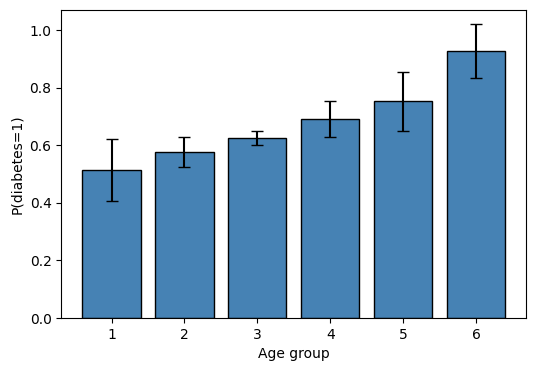

In [7]:
import matplotlib.pyplot as plt

res = GComputation(fit, at="overall", scale="identity").predict(
    atexog={"agegrp": list(range(1, 7))}
)
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_plot["agegrp"].astype(str), df_plot["estimate"],
       yerr=[df_plot["estimate"] - df_plot["ci_lower"],
             df_plot["ci_upper"] - df_plot["estimate"]],
       capsize=4, color="steelblue", edgecolor="black")
ax.set(xlabel="Age group", ylabel="P(diabetes=1)")

In [8]:
print(GComputation(fit, vcov="HC3", at="overall", scale="identity").dydx("age").summary())

            Graph Result (delta, level=0.95)           
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0106   0.0025  4.2620  0.000    0.0057, 0.0155

n = 5000
Delta-vs-sim disagreement: 12.845%
plan 1b68182@1 | κ = 0.015
